<a href="https://colab.research.google.com/github/akbar260/Notebooks/blob/main/fashion200Kprob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

step 1: installing libraries

In [2]:
!pip install datasets transformers torch faiss-cpu pillow numpy tqdm pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 76.4 MB/s eta 0:00:00


step 2: shortlisitng 5k images from 200K images dataset for embedding.

In [20]:
import os
from datasets import load_dataset
from tqdm import tqdm
import pandas as pd

OUTPUT_DIR = "all_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Stream the full dataset
ds = load_dataset("Marqo/fashion200k", split="data", streaming=True)

all_meta = []
idx = 0

for row in tqdm(ds, desc="Saving all images"):
    img = row["image"]  # PIL Image
    filename = f"img_{idx}.jpg"
    path = os.path.join(OUTPUT_DIR, filename)
    img.convert("RGB").save(path)

    all_meta.append({
        "id": idx,
        "path": path,
        "category1": row["category1"],
        "category2": row["category2"],
        "text": row["text"],
        "item_ID": row["item_ID"],
    })
    idx += 1

print(f"Total images saved: {idx}")
pd.DataFrame(all_meta).to_csv("full_metadata.csv", index=False)

Saving all images: 201624it [07:23, 454.96it/s]


Total images saved: 201624


step 3: embedding the 5k images shortlisted using CLIP.

In [24]:
import torch
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import numpy as np
import pandas as pd
import time
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

meta = pd.read_csv("full_metadata.csv")

BATCH_SIZE = 128  # try 256 if you have a strong GPU (A100/T4 with enough VRAM); lower to 64 if you hit OOM

def get_embeddings_batch(image_paths):
    images = [Image.open(p).convert("RGB") for p in image_paths]
    inputs = processor(images=images, return_tensors="pt").to(device)

    with torch.no_grad():
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device == "cuda")):
            output = model.get_image_features(pixel_values=inputs["pixel_values"])

    if isinstance(output, torch.Tensor):
        feats = output
    else:
        feats = getattr(output, "image_embeds", None) or getattr(output, "pooler_output", None)

    feats = feats.float()
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy()


all_paths = meta["path"].tolist()
embeddings = []
batch_times = []

overall_start = time.perf_counter()

for i in tqdm(range(0, len(all_paths), BATCH_SIZE), desc="Embedding images (batched)"):
    batch_paths = all_paths[i:i + BATCH_SIZE]

    batch_start = time.perf_counter()
    batch_embeds = get_embeddings_batch(batch_paths)
    if device == "cuda":
        torch.cuda.synchronize()  # wait for GPU work to finish before recording time
    batch_end = time.perf_counter()

    batch_times.append(batch_end - batch_start)
    embeddings.append(batch_embeds)

overall_end = time.perf_counter()

embeddings = np.vstack(embeddings).astype("float32")
np.save("embeddings.npy", embeddings)

total_time = overall_end - overall_start
avg_batch_time = np.mean(batch_times)
images_per_sec = len(all_paths) / total_time

print(f"\nFinal embeddings shape: {embeddings.shape}")
print(f"Total embedding time   : {total_time:.2f} sec")
print(f"Average batch time     : {avg_batch_time:.4f} sec (batch size = {BATCH_SIZE})")
print(f"Throughput             : {images_per_sec:.1f} images/sec")

Using device: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Embedding images (batched): 100%|██████████| 1576/1576 [14:53<00:00,  1.76it/s]



Final embeddings shape: (201624, 512)
Total embedding time   : 893.74 sec
Average batch time     : 0.5659 sec (batch size = 128)
Throughput             : 225.6 images/sec


step 4: storing the embedded images in a FAISS vector database

In [25]:
import faiss
import numpy as np

embeddings = np.load("embeddings.npy")
dim = embeddings.shape[1]

index = faiss.IndexFlatIP(dim)  # cosine similarity (vectors are normalized)
index.add(embeddings)

faiss.write_index(index, "fashion_index.faiss")
print("Total vectors indexed:", index.ntotal)

Total vectors indexed: 201624


step 5: searching for the provided images in the vector database

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Embedding time : 0.0144 sec
FAISS search time: 0.0376 sec
Total time      : 0.0520 sec

                             path category1          category2     score
199734  all_images/img_199734.jpg      tops           t-shirts  0.912353
179418  all_images/img_179418.jpg      tops  short sleeve tops  0.905231
182755  all_images/img_182755.jpg      tops  short sleeve tops  0.902384
200117  all_images/img_200117.jpg      tops           t-shirts  0.893451
185392  all_images/img_185392.jpg      tops  short sleeve tops  0.886481
178822  all_images/img_178822.jpg      tops  short sleeve tops  0.884641
178819  all_images/img_178819.jpg      tops  short sleeve tops  0.883632
199733  all_images/img_199733.jpg      tops           t-shirts  0.882524
200905  all_images/img_200905.jpg      tops           t-shirts  0.882265
183789  all_images/img_183789.jpg      tops  short sleeve tops  0.881907


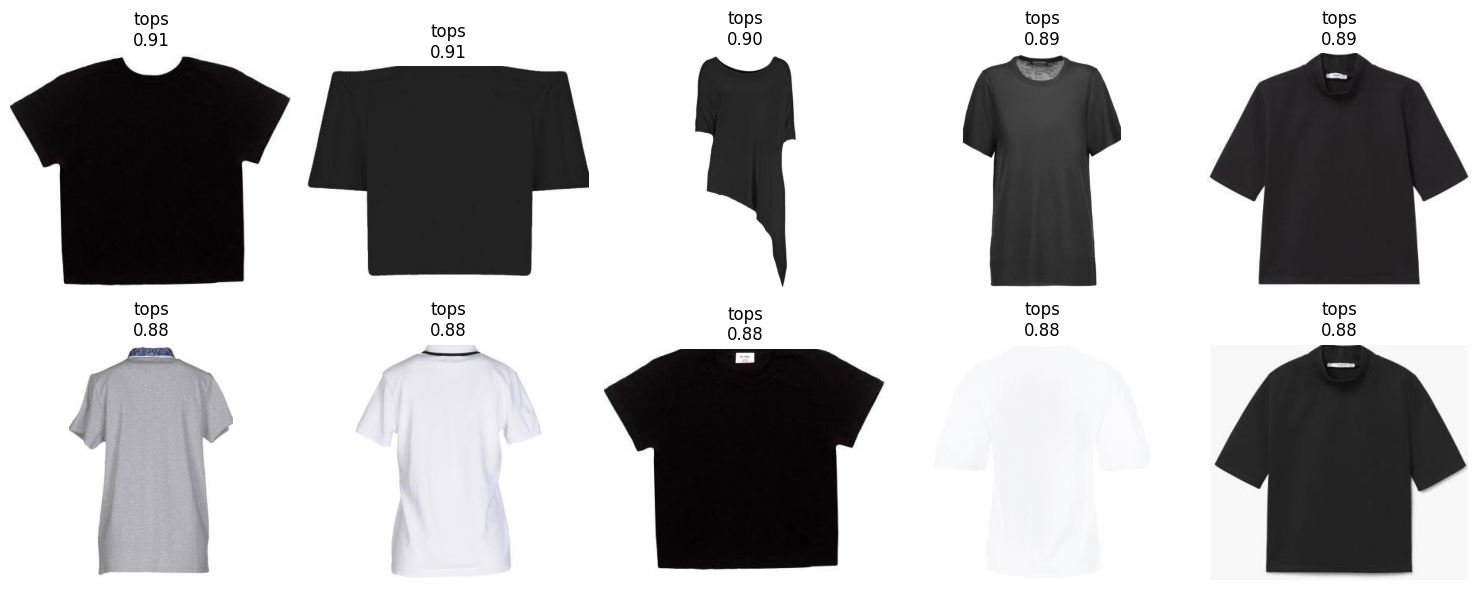

In [28]:
import faiss
import pandas as pd
import numpy as np
import torch
import time
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

index = faiss.read_index("fashion_index.faiss")
meta = pd.read_csv("full_metadata.csv")


def embed_query(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        output = model.get_image_features(pixel_values=inputs["pixel_values"])

    if isinstance(output, torch.Tensor):
        feats = output
    else:
        feats = getattr(output, "image_embeds", None) or getattr(output, "pooler_output", None)
        if feats is None:
            raise TypeError(f"Unexpected output type from get_image_features: {type(output)}")

    feats = feats / feats.norm(dim=-1, keepdim=True)
    query_vec = feats.cpu().numpy().astype("float32")

    if query_vec.ndim == 1:
        query_vec = query_vec.reshape(1, -1)

    return query_vec


def search(image_path, top_k=10):
    total_start = time.perf_counter()

    # --- Embedding time ---
    embed_start = time.perf_counter()
    query_vec = embed_query(image_path)
    if device == "cuda":
        torch.cuda.synchronize()  # ensure GPU work is finished before stopping the timer
    embed_end = time.perf_counter()

    # --- FAISS search time ---
    search_start = time.perf_counter()
    scores, indices = index.search(query_vec, top_k)
    search_end = time.perf_counter()

    total_end = time.perf_counter()

    timings = {
        "embedding_time_sec": embed_end - embed_start,
        "faiss_search_time_sec": search_end - search_start,
        "total_time_sec": total_end - total_start,
    }

    results = meta.iloc[indices[0]].copy()
    results["score"] = scores[0]

    return results, timings


# --- Run the search ---
query_image = "/content/query2.jfif"

results, timings = search(query_image, top_k=10)

print(f"Embedding time : {timings['embedding_time_sec']:.4f} sec")
print(f"FAISS search time: {timings['faiss_search_time_sec']:.4f} sec")
print(f"Total time      : {timings['total_time_sec']:.4f} sec")
print()
print(results[["path", "category1", "category2", "score"]])

# --- Visualize results ---
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, (_, row) in zip(axes.flatten(), results.iterrows()):
    img = Image.open(row["path"])
    ax.imshow(img)
    ax.set_title(f"{row['category1']}\n{row['score']:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [29]:
from google.colab import files
files.download('/content/embeddings.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
from google.colab import files
files.download('/content/fashion_index.faiss')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>